In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sns.set_theme(style="whitegrid")
palette = ["#4e79a7", "#f28e2b"]

sys.path.append(os.path.abspath(os.path.join('..')))
from utils.db_handler import DatabaseHandler

# Load the dataset
df = pd.DataFrame(DatabaseHandler().get_all_jobs())

# 1. First insights

In [48]:
print("--- INITIAL DATA INFO ---")
df.info()

--- INITIAL DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                2026 non-null   str           
 1   Stanowisko        2026 non-null   str           
 2   Firma             2026 non-null   str           
 3   Poziom            2026 non-null   str           
 4   Kategoria         1605 non-null   str           
 5   Technologie       2026 non-null   str           
 6   Lokalizacja       2026 non-null   str           
 7   Wynagrodzenie Od  575 non-null    float64       
 8   Wynagrodzenie Do  574 non-null    float64       
 9   Waluta            1714 non-null   str           
 10  Utworzono         2026 non-null   datetime64[us]
 11  Zaktualizowano    1605 non-null   datetime64[us]
 12  Scraped At        2026 non-null   datetime64[us]
 13  Source            2026 non-null   str           
dtypes: dateti

In [49]:
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())


--- MISSING VALUES ---
ID                     0
Stanowisko             0
Firma                  0
Poziom                 0
Kategoria            421
Technologie            0
Lokalizacja            0
Wynagrodzenie Od    1451
Wynagrodzenie Do    1452
Waluta               312
Utworzono              0
Zaktualizowano       421
Scraped At             0
Source                 0
dtype: int64


In [50]:
print("\n--- DUPLICATES ---")
print(f"Number of exact duplicate rows: {df.duplicated().sum()}")
# Check duplicates by ID
if 'ID' in df.columns:
    print(f"Number of duplicate IDs: {df.duplicated(subset=['ID']).sum()}")


--- DUPLICATES ---
Number of exact duplicate rows: 0
Number of duplicate IDs: 0


# 2. Handle missing values

## 2.1 Currency
Based on the sources from which the data was retrieved, we assume that the default currency is PLN. 

In [51]:
df["Waluta"] = df["Waluta"].fillna("PLN")

## 2.2 Category
Our primary focus is on technology. The “category” column does not add much value to the analysis. Therefore, it will be excluded from further exploratory analysis.

In [52]:
df.drop(columns=["Kategoria"], inplace=True, errors='ignore')
df.columns.tolist()

['ID',
 'Stanowisko',
 'Firma',
 'Poziom',
 'Technologie',
 'Lokalizacja',
 'Wynagrodzenie Od',
 'Wynagrodzenie Do',
 'Waluta',
 'Utworzono',
 'Zaktualizowano',
 'Scraped At',
 'Source']

## 2.3 Salaries
Before we proceed with further analysis, let's begin by presenting salaries on charts.

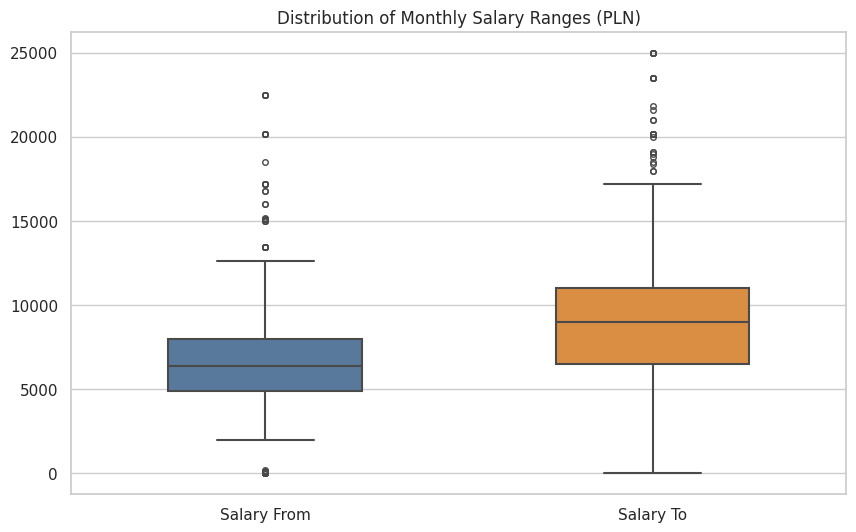

In [53]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df[["Wynagrodzenie Od", "Wynagrodzenie Do"]], 
    palette=palette,
    width=0.5,
    linewidth=1.5,
    fliersize=4 # Size of outlier points
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Salary From", "Salary To"])
plt.title("Distribution of Monthly Salary Ranges (PLN)")
plt.show()

The chart shows values below 1,000, which means that hourly rates may be listed. Let’s convert them to monthly rates, assuming that a month has 168 working hours

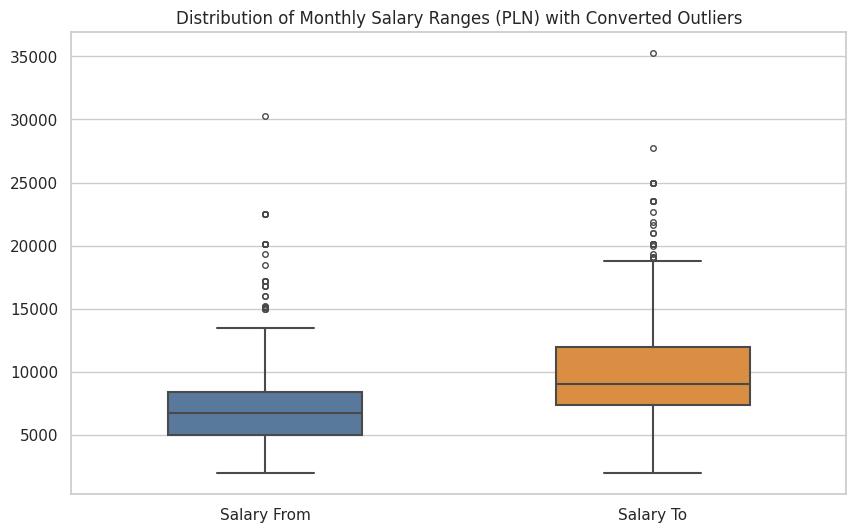

In [54]:
# Convert outliers to monthly salary
df.loc[df["Wynagrodzenie Od"] < 1000, "Wynagrodzenie Od"] = df.loc[df["Wynagrodzenie Od"] < 1000, "Wynagrodzenie Od"] * 168
df.loc[df["Wynagrodzenie Do"] < 1000, "Wynagrodzenie Do"] = df.loc[df["Wynagrodzenie Do"] < 1000, "Wynagrodzenie Do"] * 168

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df[["Wynagrodzenie Od", "Wynagrodzenie Do"]], 
    palette=palette,
    width=0.5,
    linewidth=1.5,
    fliersize=4 # Size of outlier points
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Salary From", "Salary To"])
plt.title("Distribution of Monthly Salary Ranges (PLN) with Converted Outliers")
plt.show()

Let’s plot the adjusted salaries on a graph to analyze the distribution of salaries

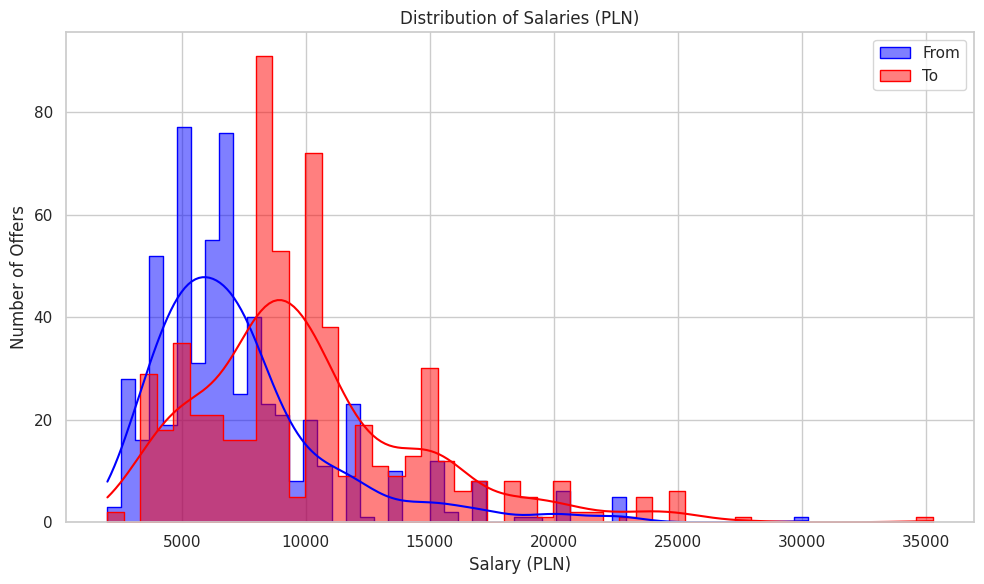

In [55]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Wynagrodzenie Od', bins=50, kde=True, color='blue', label='From', element="step")
sns.histplot(data=df, x='Wynagrodzenie Do', bins=50, kde=True, color='red', alpha=0.5, label='To', element="step")
plt.title("Distribution of Salaries (PLN)")
plt.xlabel("Salary (PLN)")
plt.ylabel("Number of Offers")
plt.legend()
plt.tight_layout()
plt.show()

## 2.4 Technologies
Currently, the technologies are displayed in a single column as a list of values. To make it easier to analyze the data, we will use the `exploded` function to convert the list into multiple columns

Before exploding: 94757 rows
After exploding: 92521 rows
Unique technologies: 929
Top 20 technologies:
Technologie
Python        396
SQL           365
Java          230
JavaScript    167
Git           144
Linux         138
C#            112
Jira          111
Azure         111
AI            101
HTML           87
Windows        79
PHP            75
TypeScript     66
C++            65
CSS            65
Docker         62
REST API       62
PostgreSQL     61
ETL            56
Name: count, dtype: int64


/tmp/ipykernel_9712/979465803.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df["Technologie"].isin(top_20_techs.index)],


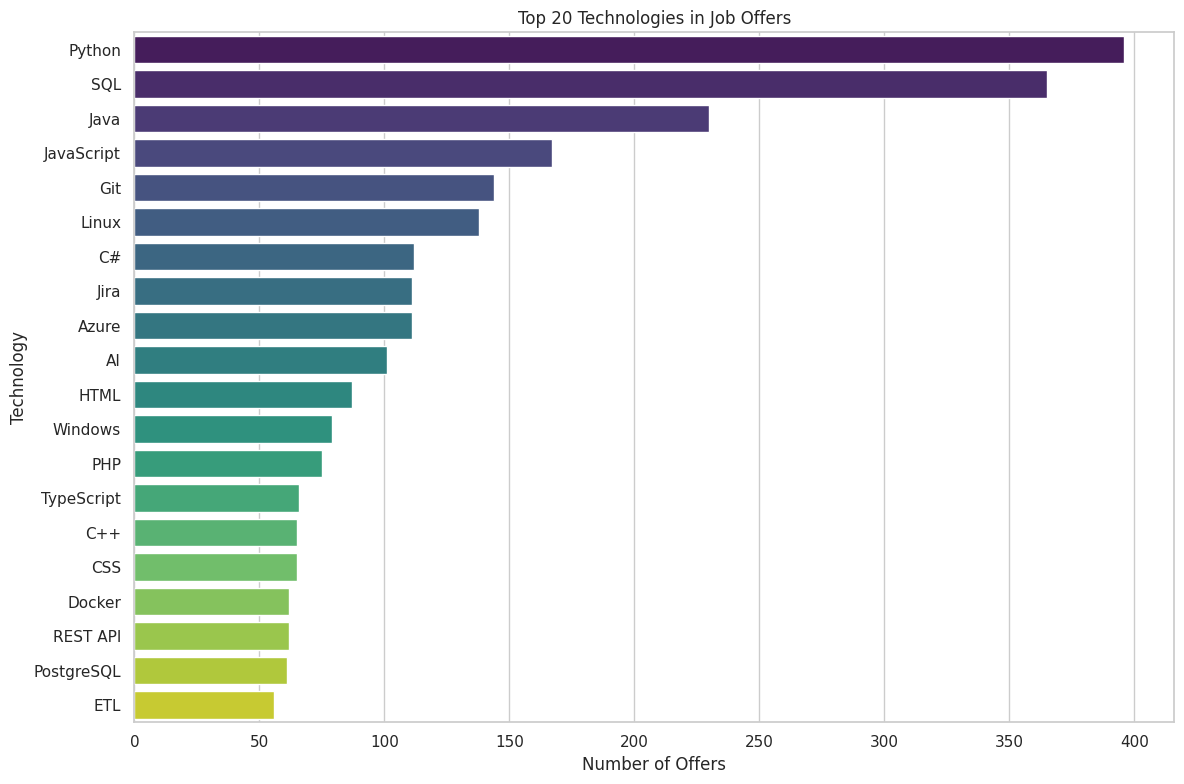

In [69]:
print(f"Before exploding: {df.size} rows")

df["Technologie"] = df["Technologie"].astype(str).str.split(',')
df = df.explode("Technologie")
df["Technologie"] = df["Technologie"].str.strip()
df = df[df["Technologie"] != "Brak danych"]

print(f"After exploding: {df.size} rows")

print(f"Unique technologies: {df['Technologie'].nunique()}")

top_20_techs = df["Technologie"].value_counts().head(20)
print(f"Top 20 technologies:\n{top_20_techs}")

plt.figure(figsize=(12, 8))
sns.countplot(data=df[df["Technologie"].isin(top_20_techs.index)], 
            y="Technologie",
            order=top_20_techs.index, 
            palette='viridis')
plt.title("Top 20 Technologies in Job Offers")
plt.xlabel("Number of Offers")
plt.ylabel("Technology")
plt.tight_layout()
plt.show()
